# VAE-GMM clusters in 2D

Embed one checkpoint's ISM library (background-subtracted foregrounds `x - mu_b`) into 2D and color by the model's hard GMM cluster. First example: a low-J, low-cluster-count run (`J8 ... drop0.5 znorm bgre`, 18 surviving clusters on peak26256).

- **Cell A** — UMAP straight on the foregrounds (cosine metric, matching the model's cosine decomposition).
- **Cell B** — PCA(50) then UMAP, the standard high-dim pipeline, to see if the same mechanisms fall out of a linear projection first.

In [56]:
import os
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
import umap
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

RESULTS_DIR = "/grid/koo/home/pmantill/projects/VBI/VAE_gmm/results"
SEAM_DIR    = "/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class VAE_GMM_eval(nn.Module):
    """Eval-only rebuild of the fitted VAE-GMM (encoder + GMM prior + decoder + background mean)."""
    def __init__(self, D, J, K, hidden, has_dropout):
        super().__init__()
        if has_dropout:
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(), nn.Dropout(0.0),
                                     nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(0.0))
        else:
            self.enc = nn.Sequential(nn.Linear(D, hidden), nn.ReLU(),
                                     nn.Linear(hidden, hidden), nn.ReLU())
        self.enc_mu = nn.Linear(hidden, J)
        self.enc_lv = nn.Linear(hidden, J)
        self.dec = nn.Sequential(nn.Linear(J, hidden), nn.ReLU(),
                                 nn.Linear(hidden, hidden), nn.ReLU(),
                                 nn.Linear(hidden, D))
        self.mu_b      = nn.Parameter(torch.zeros(D))
        self.mu_c      = nn.Parameter(torch.zeros(K, J))
        self.log_var_c = nn.Parameter(torch.zeros(K, J))
        self.alpha_raw = nn.Parameter(torch.zeros(K))

    @property
    def alpha(self):
        return F.softplus(self.alpha_raw) + 1e-4


def load_model(ckpt):
    sd = ckpt["state_dict"]
    has_dropout = "enc.3.weight" in sd
    D, hidden = sd["enc.0.weight"].shape[1], sd["enc.0.weight"].shape[0]
    J, K = sd["enc_mu.weight"].shape[0], sd["mu_c"].shape[0]
    m = VAE_GMM_eval(D, J, K, hidden, has_dropout)
    m.load_state_dict(sd, strict=False)   # background covariance log_var_b is unused here
    return m.eval().to(DEVICE), dict(D=D, J=J, K=K)


def load_X(peak, lib, preproc):
    suffix = {"100k": "", "200k": "_200k"}[lib]
    with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
        attributions = f["ism_centered"][:]                 # (N, L, 4) mean-centered ISM
    X = attributions.reshape(attributions.shape[0], -1).astype(np.float32)
    if preproc == "znorm":
        X = (X - X.mean()) / (X.std() + 1e-8)
    return X

In [57]:
# ----- pick the low-J / low-cluster example, encode the library, get hard GMM clusters -----
CKPT = "peak84030.100k.J8.K200.a0.001.w60.drop0.3.znorm.seed3"
peak    = CKPT.split(".100k")[0].split(".200k")[0]
lib     = "200k" if ".200k" in CKPT else "100k"
preproc = "znorm" if "znorm" in CKPT else "raw"

ckpt = torch.load(f"{RESULTS_DIR}/{CKPT}.pt", map_location=DEVICE, weights_only=False)
model, arch = load_model(ckpt)
X = load_X(peak, lib, preproc)                              # (N, D) flattened ISM maps
Xt = torch.from_numpy(X).to(DEVICE)

# responsibilities are analytic in (mu_z, lv_z): gamma = softmax_k(E[log pi_k] - KL[q(z|x)||N_k])
alpha = model.alpha
Elog_pi = torch.digamma(alpha) - torch.digamma(alpha.sum())
lv_c, mu_c = model.log_var_c[None], model.mu_c[None]
with torch.no_grad():
    h = model.enc(Xt)
    mu_z = model.enc_mu(h)                                  # (N, J) latent codes
    mz, lz = mu_z[:, None, :], model.enc_lv(h)[:, None, :]
    KL_k = 0.5 * (lv_c - lz + (torch.exp(lz) + (mz - mu_c)**2) * torch.exp(-lv_c) - 1.0).sum(-1)
    hard = (Elog_pi[None] - KL_k).argmax(1).cpu().numpy()   # (N,) cluster id per variant

Z = mu_z.cpu().numpy()                                      # (N, J) latent codes -- the GMM's own space
alive = np.unique(hard)
wt = hard[0]                                               # WT / reference variant is index 0
print(f"{CKPT}\nN={len(X)}  J={arch['J']}  surviving clusters={len(alive)}  WT cluster={wt}")

# one distinct color per surviving cluster (tab20 up to 20, else even HSV spacing) -- no recycling
if len(alive) <= 20:
    palette = plt.cm.tab20(np.linspace(0, 1, 20))[:len(alive)]
else:
    palette = hsv_to_rgb(np.column_stack([np.linspace(0, 1, len(alive), endpoint=False),
                                          np.full(len(alive), 0.65), np.full(len(alive), 0.9)]))
cluster_color = {k: palette[i] for i, k in enumerate(alive)}
colors = np.array([cluster_color[k] for k in hard])

peak84030.100k.J8.K200.a0.001.w60.drop0.3.znorm.seed3
N=100000  J=8  surviving clusters=44  WT cluster=33


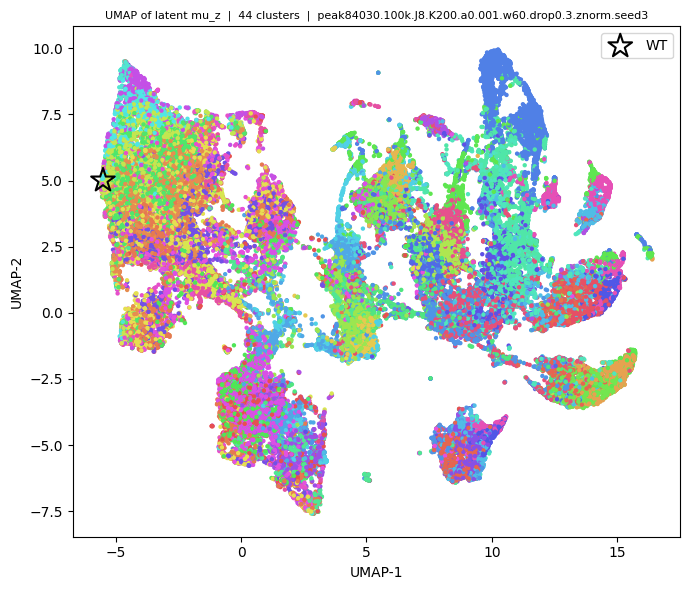

In [58]:
# ----- Cell A: UMAP straight on the latent codes mu_z (the GMM's own space) -----
emb = umap.UMAP(n_neighbors=5, metric='cosine', min_dist = 0.0).fit_transform(Z)

plt.figure(figsize=(7, 6))
plt.scatter(emb[:, 0], emb[:, 1], c=colors, s=10, linewidths=0)
plt.scatter(*emb[0], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
plt.title(f"UMAP of latent mu_z  |  {len(alive)} clusters  |  {CKPT}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend()
plt.tight_layout(); plt.show()

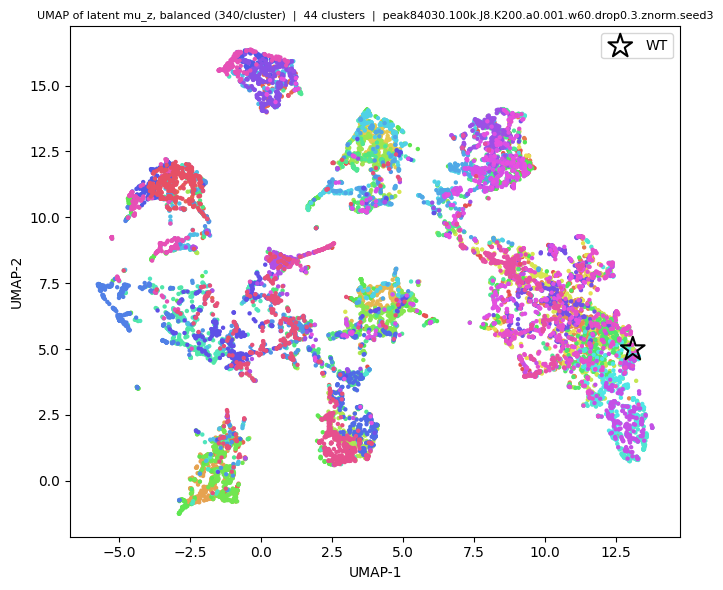

In [59]:
# ----- Cell A': same UMAP but class-balanced -- equal #seqs per cluster, so big clusters don't dominate -----
rng = np.random.default_rng(0)
n_per = min((hard == k).sum() for k in alive)               # balance to the smallest surviving cluster
idx = np.concatenate([rng.choice(np.where(hard == k)[0], n_per, replace=False) for k in alive])
if 0 not in idx:
    idx = np.append(idx, 0)                                 # always keep WT (reference, index 0)
emb_b = umap.UMAP(n_neighbors=5, metric="cosine", min_dist=0.0).fit_transform(Z[idx])
wt_pos = np.where(idx == 0)[0][0]

plt.figure(figsize=(7, 6))
plt.scatter(emb_b[:, 0], emb_b[:, 1], c=colors[idx], s=10, linewidths=0)
plt.scatter(*emb_b[wt_pos], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
plt.title(f"UMAP of latent mu_z, balanced ({n_per}/cluster)  |  {len(alive)} clusters  |  {CKPT}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend()
plt.tight_layout(); plt.show()

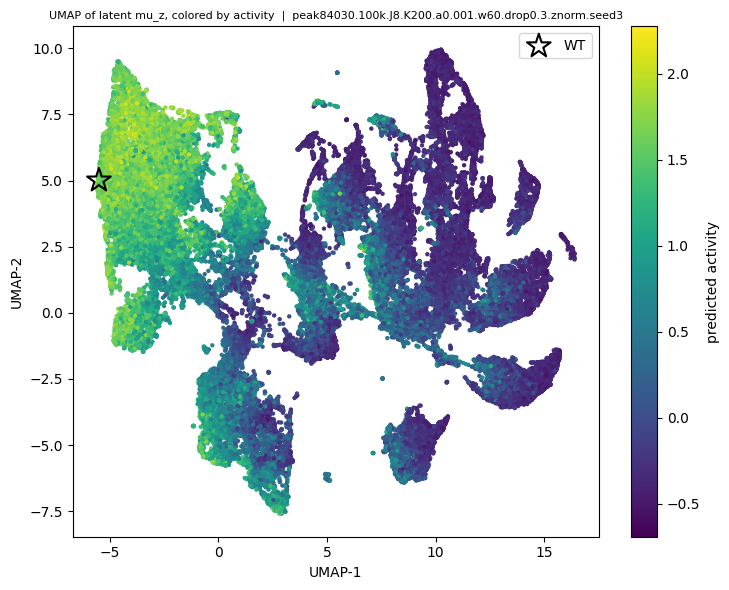

In [60]:
# ----- Cell A'': same latent UMAP, colored by predicted activity instead of cluster -----
suffix = {"100k": "", "200k": "_200k"}[lib]
with h5py.File(f"{SEAM_DIR}/ism{suffix}/{peak}.h5") as f:
    activity = f["predictions"][:]                          # (N,) model score per variant

plt.figure(figsize=(7.5, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=activity, s=10, linewidths=0, cmap="viridis")
plt.scatter(*emb[0], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
plt.colorbar(sc, label="predicted activity")
plt.title(f"UMAP of latent mu_z, colored by activity  |  {CKPT}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend()
plt.tight_layout(); plt.show()

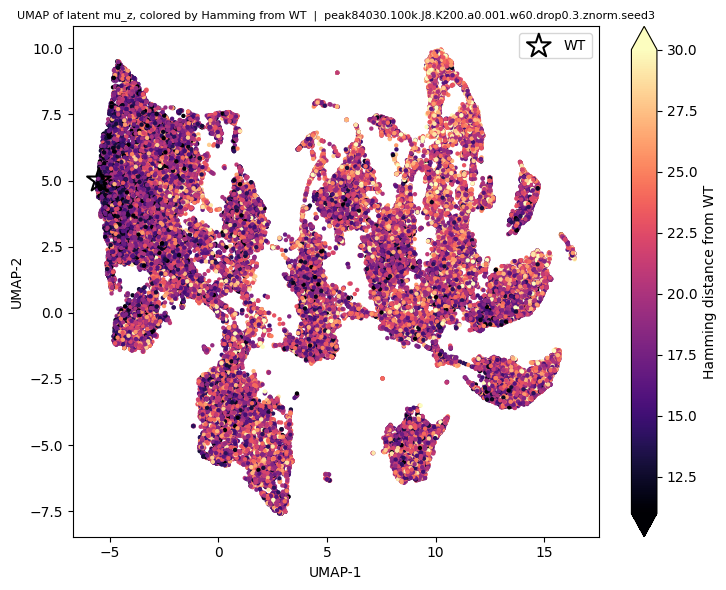

In [61]:
# ----- Cell A''': same latent UMAP, colored by Hamming distance from WT -----
mut_suffix = {"100k": "", "200k": "_200k"}[lib]
with h5py.File(f"{SEAM_DIR}/mutagenesis_lib{mut_suffix}/{peak}.h5") as f:
    seqs = f["sequences"][:].argmax(2)                      # (N, L) base index per position
    wt_seq = f["wt_sequence"][:].argmax(1)                  # (L,)
hamming = (seqs != wt_seq).sum(1)                           # (N,) #substitutions from WT

vmin, vmax = np.percentile(hamming, [2, 98])               # tighten scale -- seqs are all similar, clip outliers
plt.figure(figsize=(7.5, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], c=hamming, s=10, linewidths=0, cmap="magma", vmin=vmin, vmax=vmax)
plt.scatter(*emb[0], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
plt.colorbar(sc, label="Hamming distance from WT", extend="both")
plt.title(f"UMAP of latent mu_z, colored by Hamming from WT  |  {CKPT}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend()
plt.tight_layout(); plt.show()

/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


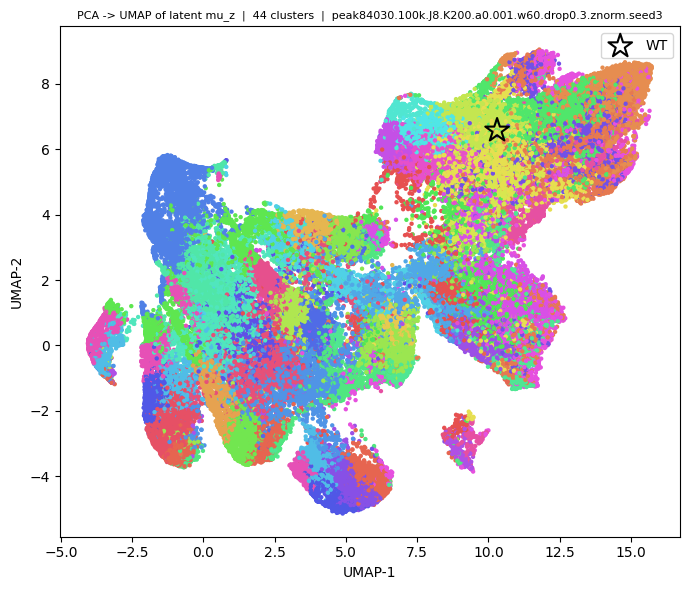

In [62]:
# ----- Cell B: PCA -> UMAP on the latent codes -----
pcs = PCA(n_components=min(50, *Z.shape)).fit_transform(Z)
emb_pca = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(pcs)

plt.figure(figsize=(7, 6))
plt.scatter(emb_pca[:, 0], emb_pca[:, 1], c=colors, s=10, linewidths=0)
plt.scatter(*emb_pca[0], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
plt.title(f"PCA -> UMAP of latent mu_z  |  {len(alive)} clusters  |  {CKPT}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend()
plt.tight_layout(); plt.show()

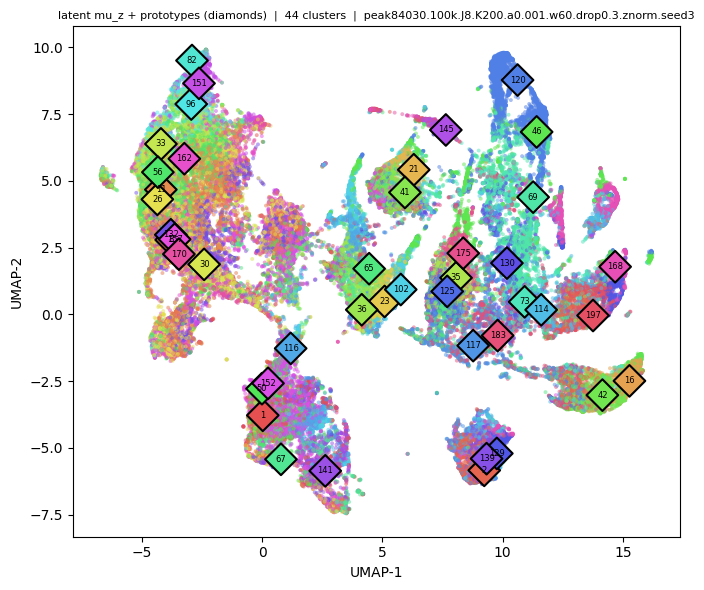

In [63]:
# ----- Cell C: latent UMAP with cluster prototypes overlaid (members should orbit their prototype) -----
# mu_c[k] is the GMM prototype's latent mean -- same J-space as the encoder codes Z, so co-embed them.
proto_z = model.mu_c.detach().cpu().numpy()[alive]          # (n_alive, J)
reducer = umap.UMAP(n_neighbors=5, metric="cosine", min_dist=0.0).fit(np.vstack([Z, proto_z]))
emb_m, emb_p = reducer.embedding_[:len(Z)], reducer.embedding_[len(Z):]

plt.figure(figsize=(7, 6))
plt.scatter(emb_m[:, 0], emb_m[:, 1], c=colors, s=8, linewidths=0, alpha=0.5)
plt.scatter(emb_p[:, 0], emb_p[:, 1], c=[cluster_color[k] for k in alive],
            s=260, marker="D", edgecolors="k", linewidths=1.5, zorder=3)
for (x, y), k in zip(emb_p, alive):
    plt.text(x, y, str(k), fontsize=6, ha="center", va="center", zorder=4)
plt.title(f"latent mu_z + prototypes (diamonds)  |  {len(alive)} clusters  |  {CKPT}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.tight_layout(); plt.show()

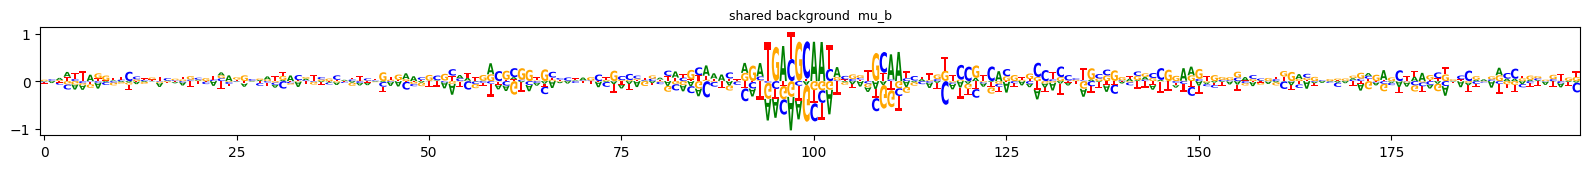

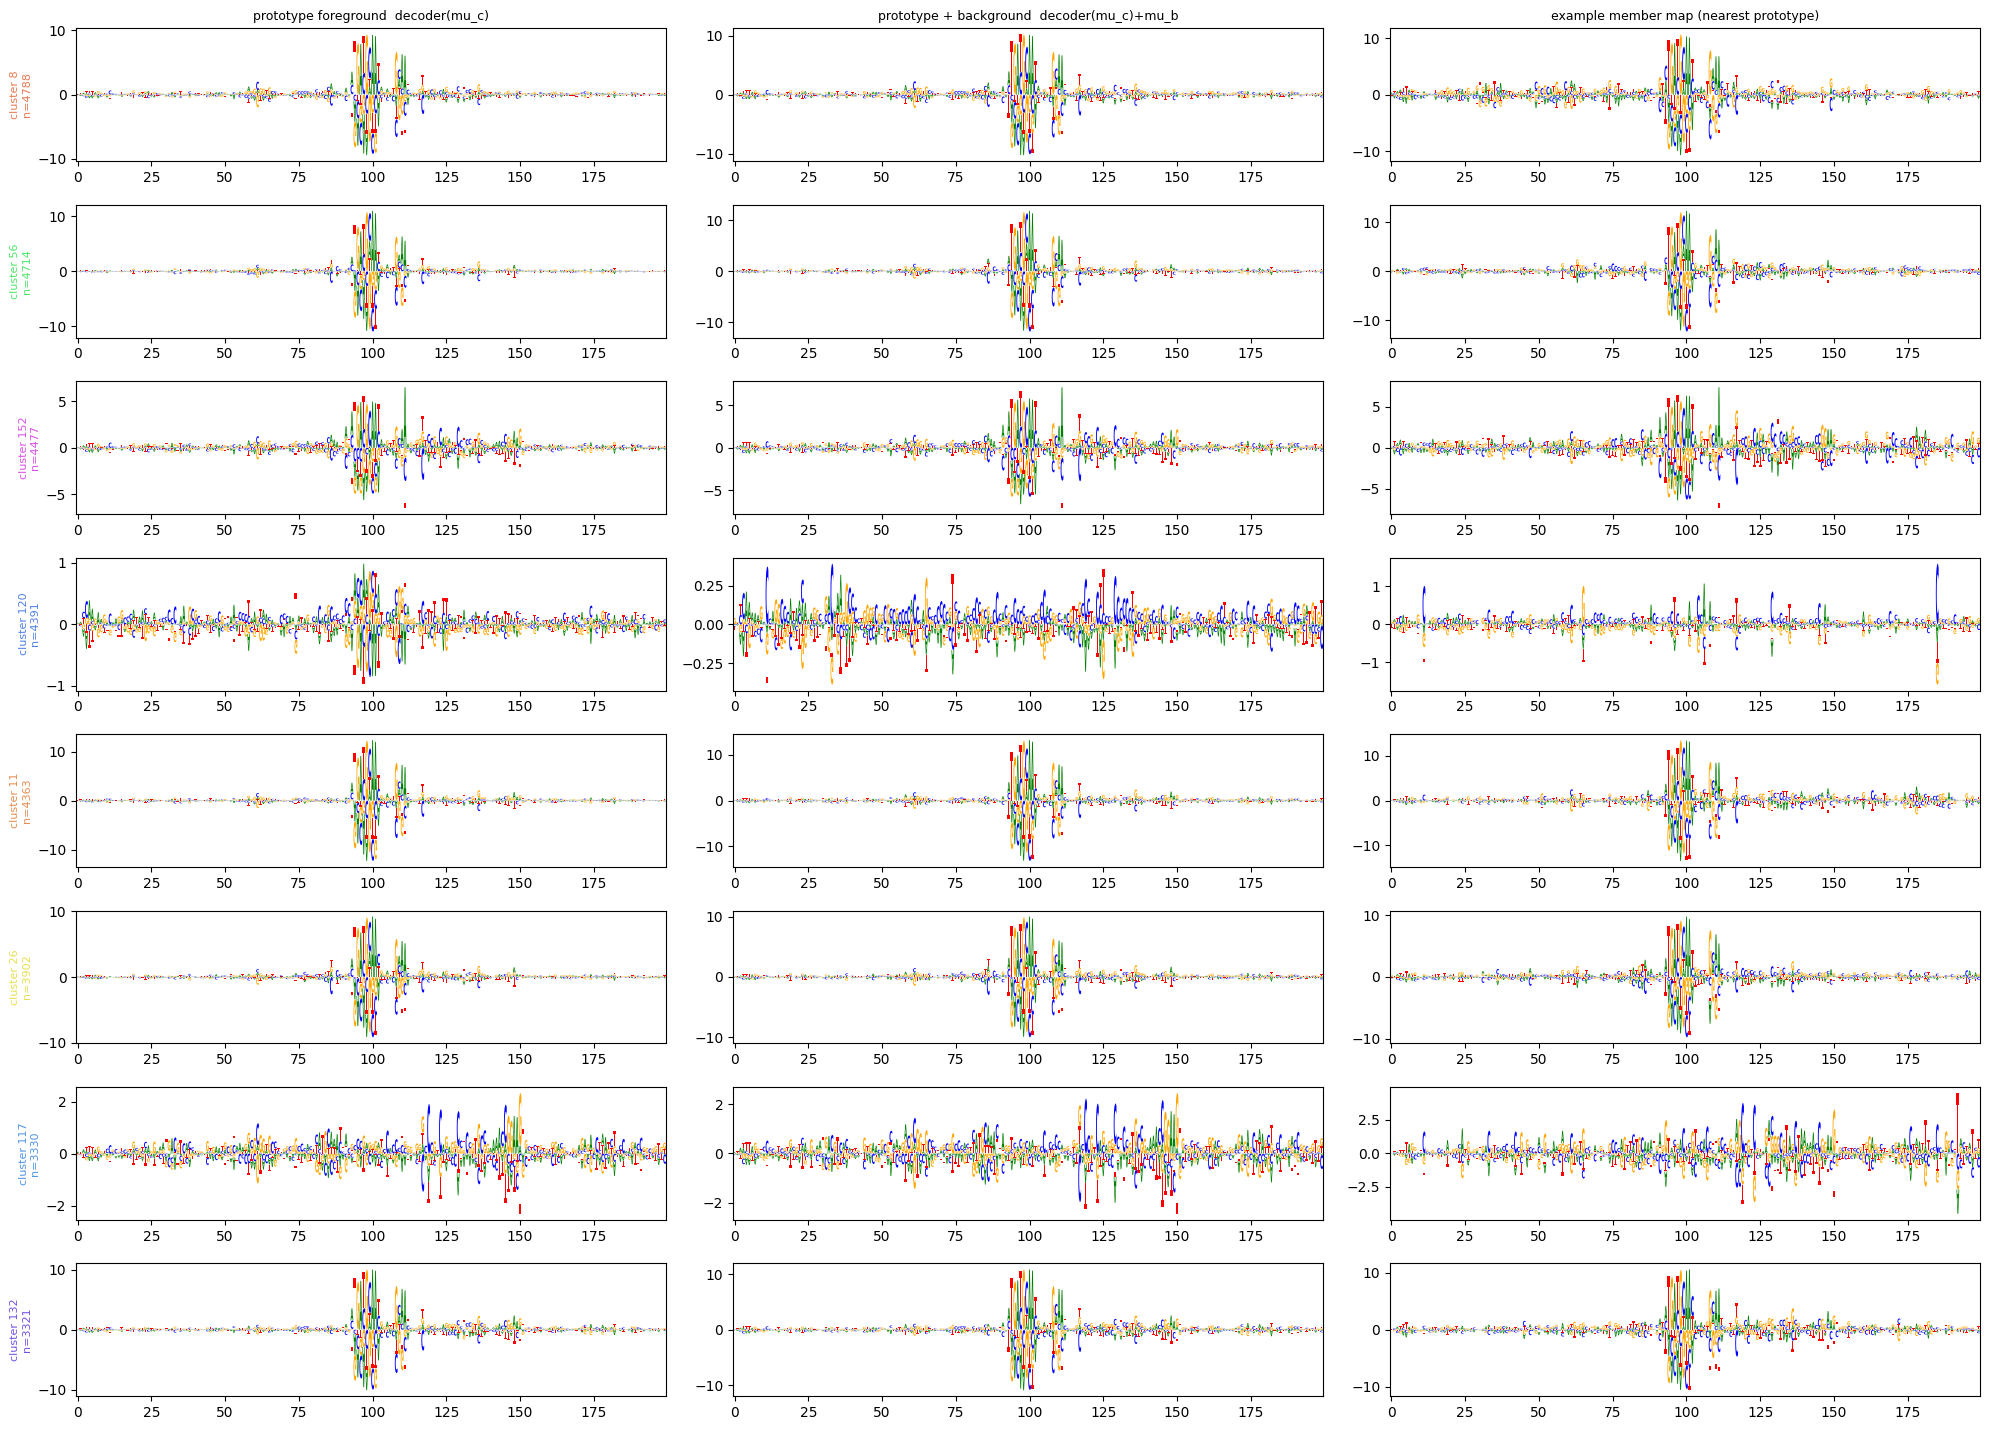

In [64]:
# ----- Cell D: mechanisms -- shared background mu_b, then per cluster: foreground, foreground+bg, real member -----
import sys; sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

L = X.shape[1] // 4
mu_b = model.mu_b.detach().cpu().numpy()                    # (D,) shared background mean
proto = model.dec(model.mu_c).detach().cpu().numpy()        # (K, D) prototype foregrounds = decoder(mu_c)
mu_c_np = model.mu_c.detach().cpu().numpy()
top = sorted(alive, key=lambda k: (hard == k).sum(), reverse=True)[:8]   # largest clusters

# shared background mu_b -- the same for every cluster, soaks up the non-cluster-specific part of every map
figb, axb = plt.subplots(figsize=(16, 1.8))
fast_logo(mu_b.reshape(L, 4), axb)
axb.set_title("shared background  mu_b", fontsize=9)
plt.tight_layout(); plt.show()

# per cluster: prototype foreground, prototype+bg (= what a member should look like), and a real member
fig, axes = plt.subplots(len(top), 3, figsize=(20, 1.8 * len(top)))
for row, k in enumerate(top):
    members = np.where(hard == k)[0]
    rep = members[np.linalg.norm(Z[members] - mu_c_np[k], axis=1).argmin()]   # member nearest prototype
    fast_logo(proto[k].reshape(L, 4), axes[row, 0])
    fast_logo((proto[k] + mu_b).reshape(L, 4), axes[row, 1])
    fast_logo(X[rep].reshape(L, 4), axes[row, 2])
    axes[row, 0].set_ylabel(f"cluster {k}\nn={len(members)}", color=cluster_color[k], fontsize=8)
    if row == 0:
        axes[row, 0].set_title("prototype foreground  decoder(mu_c)", fontsize=9)
        axes[row, 1].set_title("prototype + background  decoder(mu_c)+mu_b", fontsize=9)
        axes[row, 2].set_title("example member map (nearest prototype)", fontsize=9)
plt.tight_layout(); plt.show()

peak84030.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3
surviving clusters=78  WT cluster=85


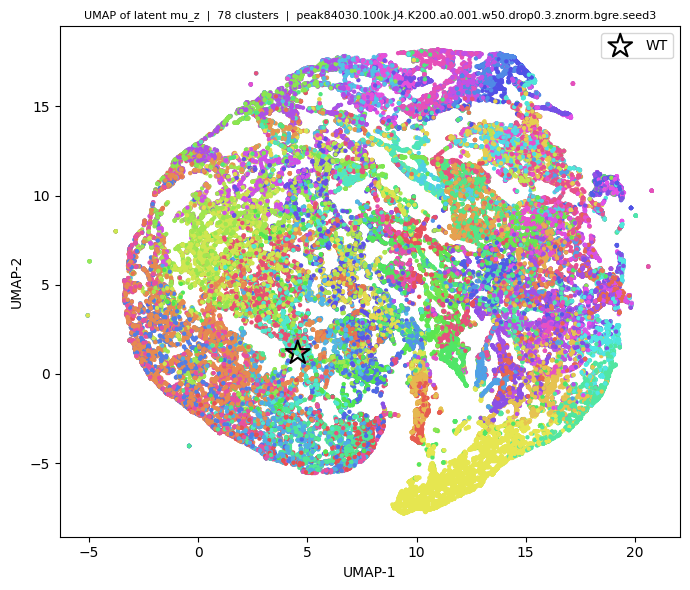

In [65]:
# ----- Cell E: second run on the same seq -- J4 w50 drop0.3 znorm bgre -- comparison -----
CKPT2 = "peak84030.100k.J4.K200.a0.001.w50.drop0.3.znorm.bgre.seed3"
model2, arch2 = load_model(torch.load(f"{RESULTS_DIR}/{CKPT2}.pt", map_location=DEVICE, weights_only=False))
X2 = load_X(peak, lib, "znorm")                            # znorm token -> global-scalar z-norm
Xt2 = torch.from_numpy(X2).to(DEVICE)

alpha2 = model2.alpha
Elog_pi2 = torch.digamma(alpha2) - torch.digamma(alpha2.sum())
lv_c2, mu_c2 = model2.log_var_c[None], model2.mu_c[None]
with torch.no_grad():
    h2 = model2.enc(Xt2)
    mu_z2 = model2.enc_mu(h2)
    mz2, lz2 = mu_z2[:, None, :], model2.enc_lv(h2)[:, None, :]
    KL_k2 = 0.5 * (lv_c2 - lz2 + (torch.exp(lz2) + (mz2 - mu_c2)**2) * torch.exp(-lv_c2) - 1.0).sum(-1)
    hard2 = (Elog_pi2[None] - KL_k2).argmax(1).cpu().numpy()
Z2 = mu_z2.cpu().numpy()
alive2 = np.unique(hard2)
print(f"{CKPT2}\nsurviving clusters={len(alive2)}  WT cluster={hard2[0]}")

# distinct color per cluster -- many clusters -> HSV spacing (no recycling)
pal2 = hsv_to_rgb(np.column_stack([np.linspace(0, 1, len(alive2), endpoint=False),
                                   np.full(len(alive2), 0.65), np.full(len(alive2), 0.9)]))
color2 = {k: pal2[i] for i, k in enumerate(alive2)}
colors2 = np.array([color2[k] for k in hard2])

emb2 = umap.UMAP(n_neighbors=5, metric="cosine", min_dist=0.0).fit_transform(Z2)
plt.figure(figsize=(7, 6))
plt.scatter(emb2[:, 0], emb2[:, 1], c=colors2, s=10, linewidths=0)
plt.scatter(*emb2[0], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
plt.title(f"UMAP of latent mu_z  |  {len(alive2)} clusters  |  {CKPT2}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend()
plt.tight_layout(); plt.show()

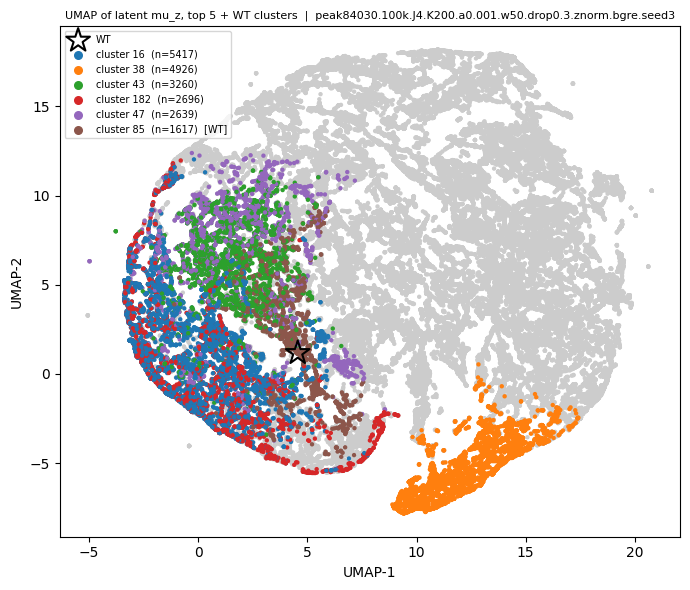

In [66]:
# ----- Cell F: same second-run UMAP, only the top-5 clusters + WT cluster colored, everything else gray -----
top5 = sorted(alive2, key=lambda k: (hard2 == k).sum(), reverse=True)[:5]
wt2 = hard2[0]
show = top5 + ([wt2] if wt2 not in top5 else [])                  # top-5 plus the WT's own cluster
show_color = {k: plt.cm.tab10(i) for i, k in enumerate(show)}
c5 = np.array([show_color.get(k, (0.8, 0.8, 0.8, 1.0)) for k in hard2])
order = np.argsort([k in show for k in hard2])                     # draw gray first, highlighted on top

plt.figure(figsize=(7, 6))
plt.scatter(emb2[order, 0], emb2[order, 1], c=c5[order], s=10, linewidths=0)
plt.scatter(*emb2[0], marker="*", s=320, c="none", edgecolors="k", linewidths=1.5, label="WT")
for k in show:
    tag = "  [WT]" if k == wt2 else ""
    plt.scatter([], [], c=[show_color[k]], s=30, label=f"cluster {k}  (n={(hard2 == k).sum()}){tag}")
plt.title(f"UMAP of latent mu_z, top 5 + WT clusters  |  {CKPT2}", fontsize=8)
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.legend(fontsize=7)
plt.tight_layout(); plt.show()

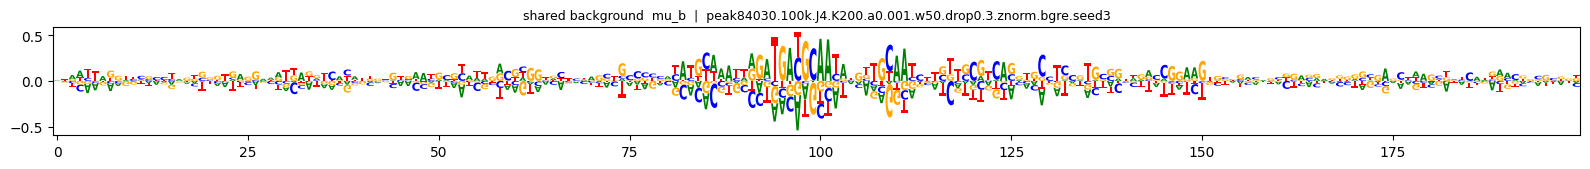

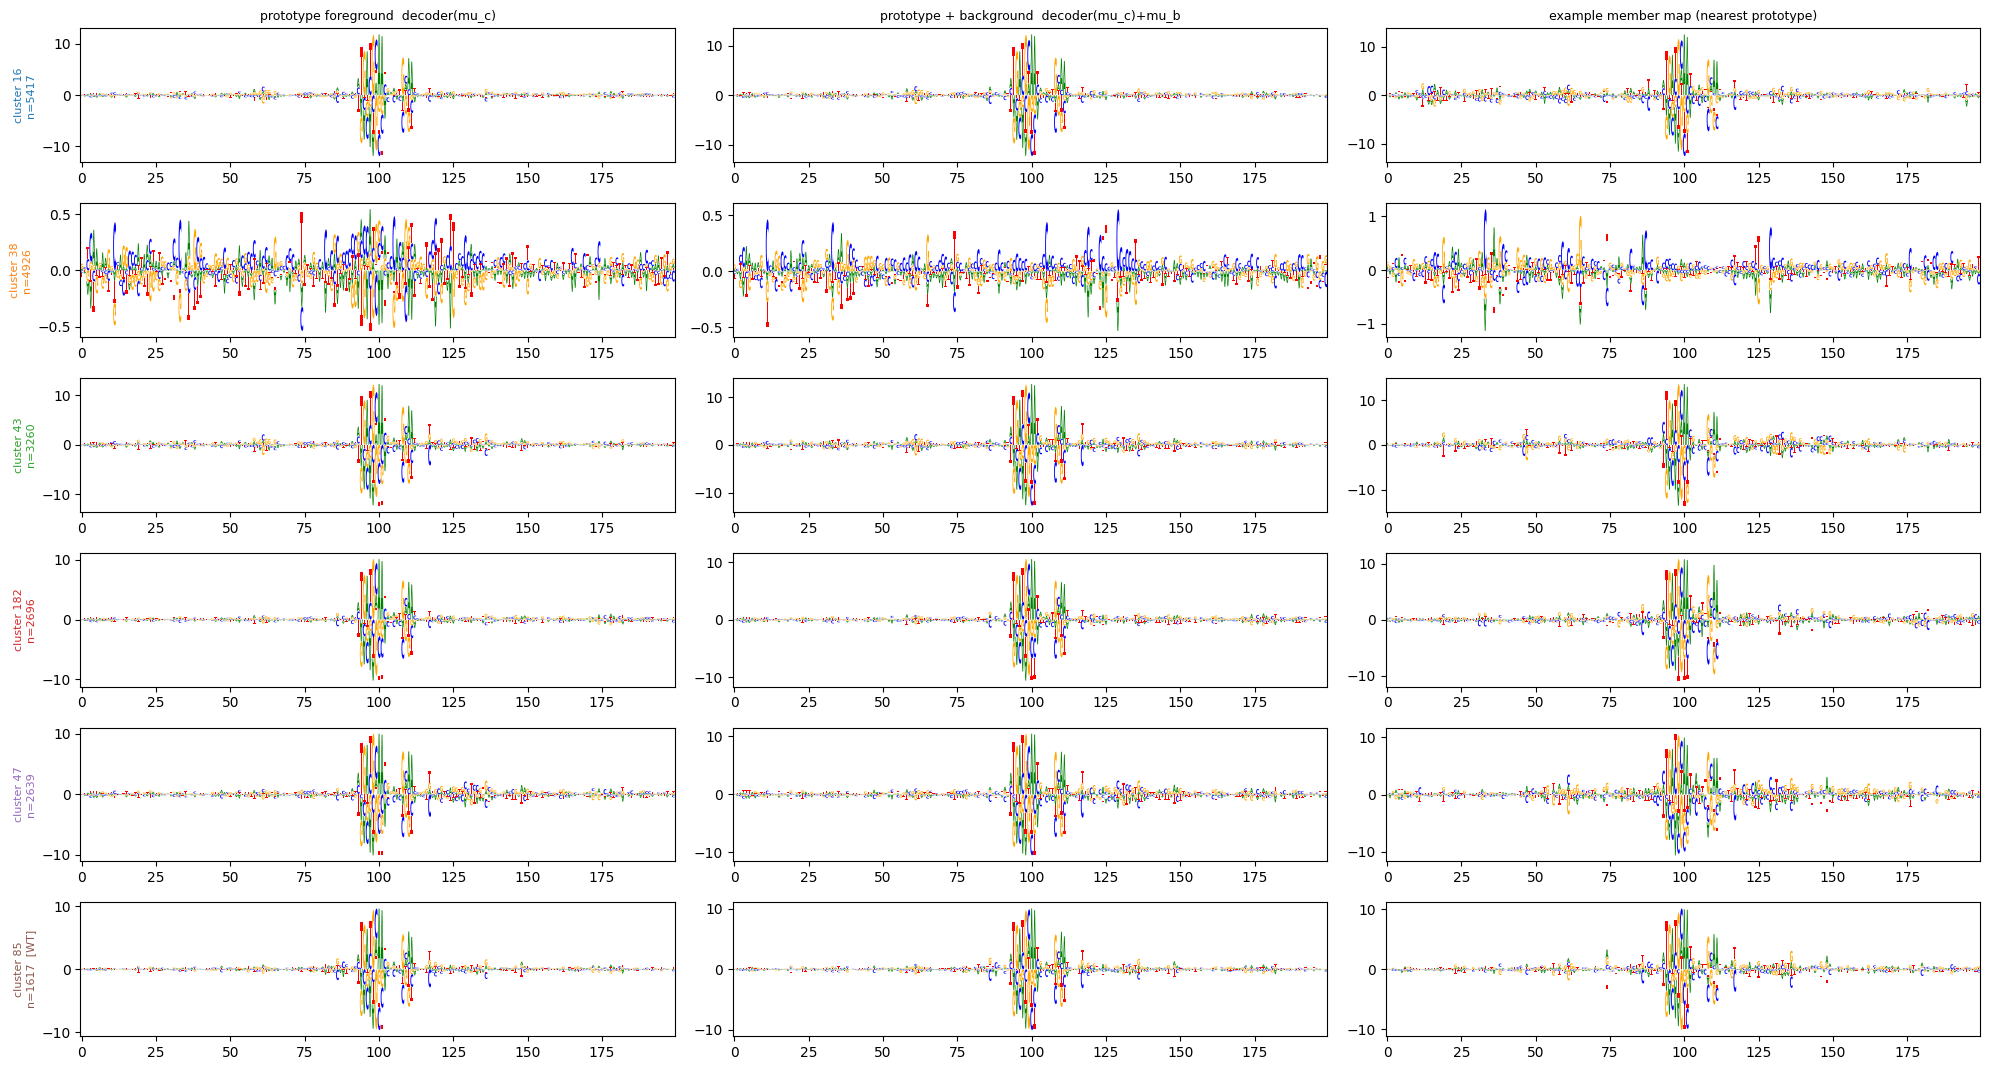

In [67]:
# ----- Cell G: prototypes (+ background) for the top-5 + WT clusters of the second run -----
import sys; sys.path.insert(0, "/grid/koo/home/pmantill/projects/EigenMaps/eigen-interactions")
from fast_logo import fast_logo

L = X2.shape[1] // 4
proto2 = model2.dec(model2.mu_c).detach().cpu().numpy()     # (K, D) prototype foregrounds
mu_b2 = model2.mu_b.detach().cpu().numpy()                  # (D,) shared background
mu_c2_np = model2.mu_c.detach().cpu().numpy()

figb, axb = plt.subplots(figsize=(16, 1.8))
fast_logo(mu_b2.reshape(L, 4), axb)
axb.set_title(f"shared background  mu_b  |  {CKPT2}", fontsize=9)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(len(show), 3, figsize=(20, 1.8 * len(show)))
for row, k in enumerate(show):
    members = np.where(hard2 == k)[0]
    rep = members[np.linalg.norm(Z2[members] - mu_c2_np[k], axis=1).argmin()]
    fast_logo(proto2[k].reshape(L, 4), axes[row, 0])
    fast_logo((proto2[k] + mu_b2).reshape(L, 4), axes[row, 1])
    fast_logo(X2[rep].reshape(L, 4), axes[row, 2])
    lbl = f"cluster {k}\nn={len(members)}" + ("  [WT]" if k == wt2 else "")
    axes[row, 0].set_ylabel(lbl, color=show_color[k], fontsize=8)
    if row == 0:
        axes[row, 0].set_title("prototype foreground  decoder(mu_c)", fontsize=9)
        axes[row, 1].set_title("prototype + background  decoder(mu_c)+mu_b", fontsize=9)
        axes[row, 2].set_title("example member map (nearest prototype)", fontsize=9)
plt.tight_layout(); plt.show()